# European option pricing: three consistent methods

This notebook develops the functions from the original `price.ipynb` and compares the Black-Scholes closed form, the Cox-Ross-Rubinstein tree, and risk-neutral Monte Carlo. The common benchmark is $S_0=36$, $K=35$, $T=1$, $r=6\%$, and $\sigma=20\%$.

Under the model assumptions, all three methods calculate the same discounted risk-neutral payoff. Their numerical errors differ: the tree has time-discretization error, while Monte Carlo has sampling error.

In [9]:
from pathlib import Path
import sys

search_locations = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next((path for path in search_locations if (path / 'pricing_hedging').is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Run this notebook from the project folder or its notebooks folder.')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np

from pricing_hedging import (
    black_scholes_price, crr_price, monte_carlo_price, simulate_gbm_paths,
)

plt.style.use('seaborn-v0_8-whitegrid')
print(f'Python environment: {sys.executable}')

Python environment: C:\Users\asus\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


In [10]:
S0 = 36.0
K = 35.0
tau = 1.0
r = 0.06
sigma = 0.20
option_type = 'call'

bs = black_scholes_price(sigma, r, tau, K, S0, option_type)
tree = crr_price(sigma, r, tau, 1_000, S0, K, option_type)
mc = monte_carlo_price(S0, r, sigma, tau, 200_000, K, option_type, seed=42)

print(f'Black-Scholes: {bs:.6f}')
print(f'CRR (1,000 steps): {tree:.6f}')
print(f"Monte Carlo: {mc['price']:.6f}  95% CI={mc['confidence_interval']}")

Black-Scholes: 4.527297
CRR (1,000 steps): 4.527498
Monte Carlo: 4.530967  95% CI=(4.505901080846533, 4.556032017249947)


## CRR convergence

The CRR estimate approaches the closed-form price as the number of time steps grows. The familiar even-odd oscillation comes from whether the strike lies close to a terminal tree node.

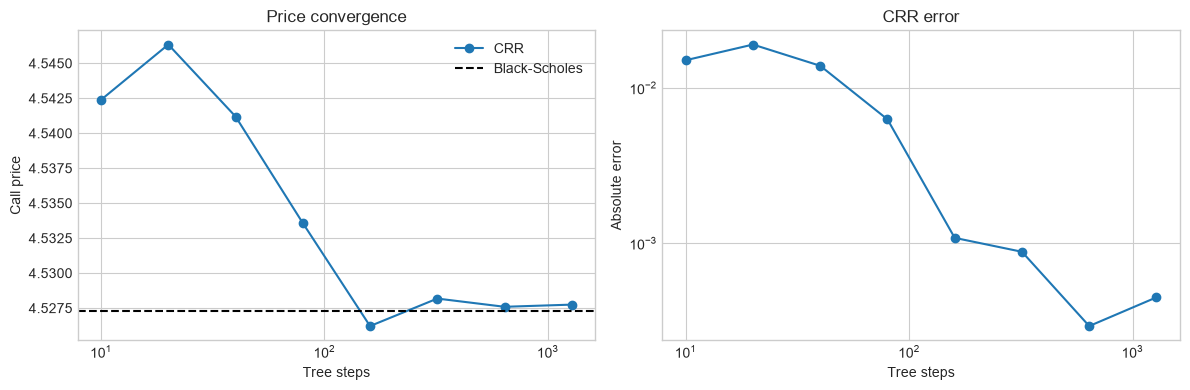

In [11]:
tree_steps = np.array([10, 20, 40, 80, 160, 320, 640, 1_280])
tree_prices = np.array([crr_price(sigma, r, tau, int(n), S0, K, option_type) for n in tree_steps])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(tree_steps, tree_prices, 'o-', label='CRR')
axes[0].axhline(bs, color='black', linestyle='--', label='Black-Scholes')
axes[0].set(xlabel='Tree steps', ylabel='Call price', xscale='log', title='Price convergence')
axes[0].legend()
axes[1].loglog(tree_steps, np.abs(tree_prices - bs), 'o-')
axes[1].set(xlabel='Tree steps', ylabel='Absolute error', title='CRR error')
plt.tight_layout()

## Monte Carlo convergence and uncertainty

Each estimate below uses a separate seeded experiment. The vertical bars are 95% confidence intervals computed from the discounted payoff sample.

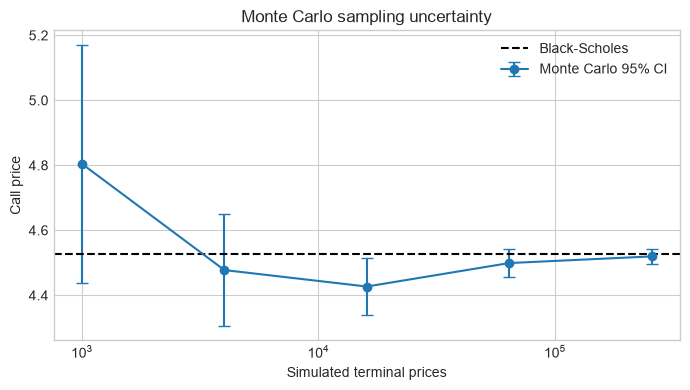

In [12]:
path_counts = np.array([1_000, 4_000, 16_000, 64_000, 256_000])
mc_results = [monte_carlo_price(S0, r, sigma, tau, int(n), K, option_type, seed=100 + i) for i, n in enumerate(path_counts)]
estimates = np.array([result['price'] for result in mc_results])
errors = 1.96 * np.array([result['standard_error'] for result in mc_results])

plt.figure(figsize=(7, 4))
plt.errorbar(path_counts, estimates, yerr=errors, fmt='o-', capsize=4, label='Monte Carlo 95% CI')
plt.axhline(bs, color='black', linestyle='--', label='Black-Scholes')
plt.xscale('log')
plt.xlabel('Simulated terminal prices')
plt.ylabel('Call price')
plt.title('Monte Carlo sampling uncertainty')
plt.legend()
plt.tight_layout()

## Strikes, risk-free rates, and volatilities

The next figure checks agreement across several economic regimes. Tree resolution is fixed at 800 steps; Monte Carlo uses 100,000 terminal draws per point. For a European call on a non-dividend-paying stock, the price increases with the risk-free rate because the present value of the strike decreases.

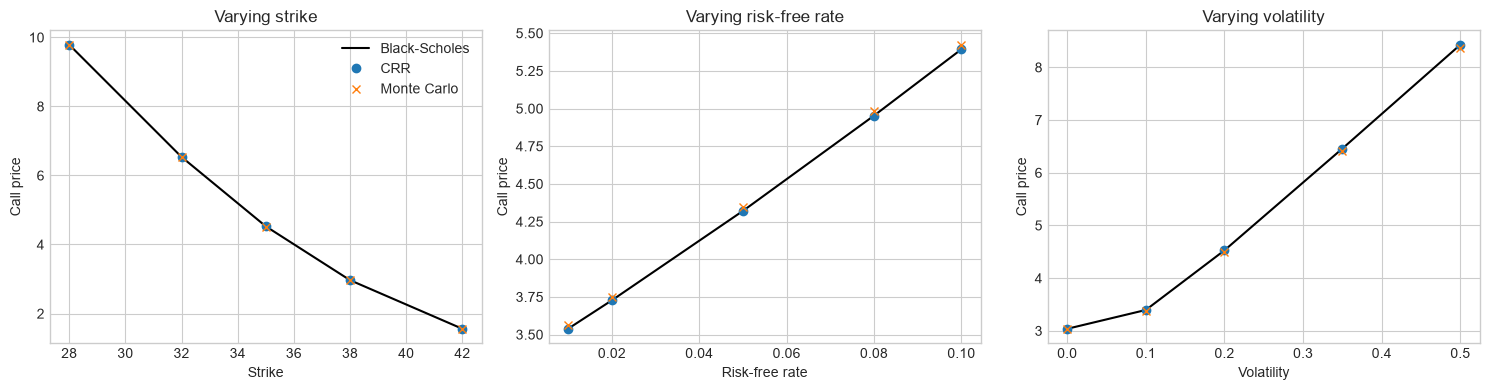

In [13]:
# Each builder returns (strike, maturity, volatility, risk-free rate).
scenarios = {
    'Strike': ([28, 32, 35, 38, 42], lambda x: (x, 1.0, 0.20, 0.06)),
    'Risk-free rate': ([0.01, 0.02, 0.05, 0.08, 0.10], lambda x: (35.0, 1.0, 0.20, x)),
    'Volatility': ([0.0, 0.10, 0.20, 0.35, 0.50], lambda x: (35.0, 1.0, x, 0.06)),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for panel, (label, (values, build)) in enumerate(scenarios.items()):
    closed, trees, simulations = [], [], []
    for i, value in enumerate(values):
        scenario_K, scenario_tau, scenario_sigma, scenario_r = build(value)
        closed.append(black_scholes_price(scenario_sigma, scenario_r, scenario_tau, scenario_K, S0, option_type))
        trees.append(crr_price(scenario_sigma, scenario_r, scenario_tau, 800, S0, scenario_K, option_type))
        # Reuse the same random numbers within a panel for a clearer comparison.
        simulations.append(monte_carlo_price(S0, scenario_r, scenario_sigma, scenario_tau, 100_000, scenario_K, option_type, seed=1_000 + panel)['price'])
    axes[panel].plot(values, closed, 'k-', label='Black-Scholes')
    axes[panel].plot(values, trees, 'o', label='CRR')
    axes[panel].plot(values, simulations, 'x', label='Monte Carlo')
    axes[panel].set(xlabel=label, ylabel='Call price', title=f'Varying {label.lower()}')
axes[0].legend()
plt.tight_layout()

## Full paths belong to hedging experiments

European pricing only needs the terminal distribution. Full-path simulation is therefore a separate function, ready for later discrete hedging experiments.

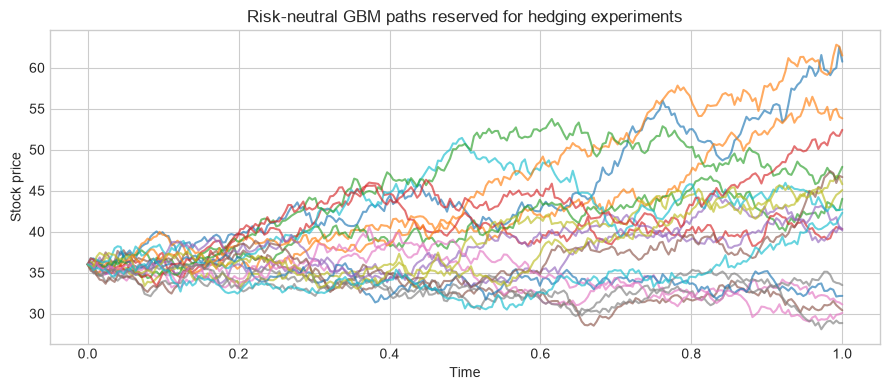

In [6]:
times, paths = simulate_gbm_paths(S0, r, sigma, tau=1.0, N=252, n_paths=20, seed=5)
plt.figure(figsize=(9, 4))
plt.plot(times, paths.T, alpha=0.65)
plt.xlabel('Time')
plt.ylabel('Stock price')
plt.title('Risk-neutral GBM paths reserved for hedging experiments')
plt.tight_layout()